In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv('/content/titanic_toy.csv')
df.head()


,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [8]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [10]:
X_train.shape

(712, 3)

In [12]:
X_train.isnull().mean()

,0
Age,0.196629
Fare,0.050562
Family,0.000000


In [14]:
age_mean=X_train['Age'].mean()
age_median=X_train['Age'].median()
fare_mean=X_train['Fare'].mean()
fare_median=X_train['Fare'].median()

In [15]:
X_train['Age_mean']=df['Age'].fillna(age_mean)
X_train['Age_median']=df['Age'].fillna(age_median)
X_train['Fare_mean']=df['Fare'].fillna(age_mean)
X_train['Fare_median']=df['Fare'].fillna(age_median)

In [18]:
X_train.head(10)


,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
331,45.5,28.5000,0,45.500000,45.5,28.5000,28.5000
733,23.0,13.0000,0,23.000000,23.0,13.0000,13.0000
382,32.0,7.9250,0,32.000000,32.0,7.9250,7.9250
704,26.0,7.8542,1,26.000000,26.0,7.8542,7.8542
813,6.0,31.2750,6,6.000000,6.0,31.2750,31.2750
118,24.0,247.5208,1,24.000000,24.0,247.5208,247.5208
536,45.0,26.5500,0,45.000000,45.0,26.5500,26.5500
361,29.0,27.7208,1,29.000000,29.0,27.7208,27.7208
29,NaN,7.8958,0,29.498846,28.0,7.8958,7.8958
55,NaN,35.5000,0,29.498846,28.0,35.5000,35.5000


In [19]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  210.2517072477438
Age Variance after median imputation:  169.20731007048096
Age Variance after mean imputation:  168.8519336687225
Original Fare variable variance:  2761.031434948639
Fare Variance after median imputation:  2622.2135607276828
Fare Variance after mean imputation:  2621.6705110298403


<Axes: ylabel='Density'>

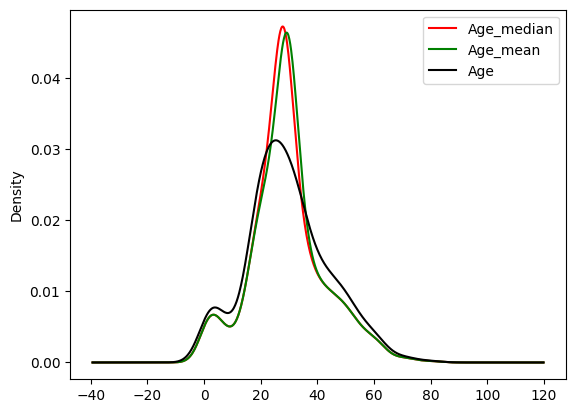

In [27]:
X_train['Age_median'].plot(kind='kde', color='red',legend=True)
X_train['Age_mean'].plot(kind='kde', color='green',legend=True)
X_train['Age'].plot(kind='kde', color='black',legend=True)

<Axes: ylabel='Density'>

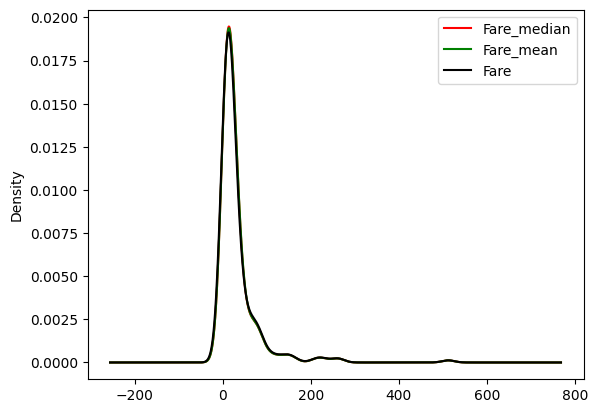

In [28]:
X_train['Fare_median'].plot(kind='kde', color='red',legend=True)
X_train['Fare_mean'].plot(kind='kde', color='green',legend=True)
X_train['Fare'].plot(kind='kde', color='black',legend=True)

In [29]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088692,0.088561
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204992,0.204985
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085711,0.085591
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.090894,0.090764
Fare_mean,0.088692,1.000000,0.204992,0.085711,0.090894,1.000000,0.999979
Fare_median,0.088561,1.000000,0.204985,0.085591,0.090764,0.999979,1.000000


<Axes: >

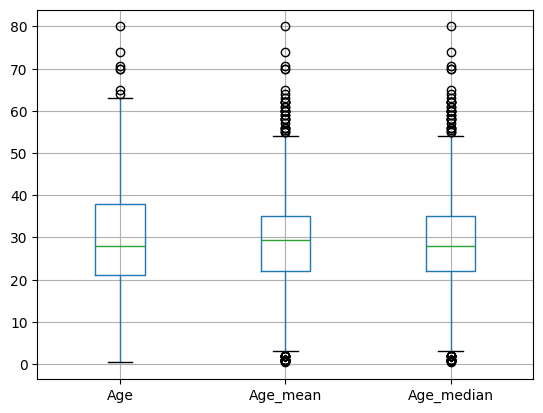

In [33]:
X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

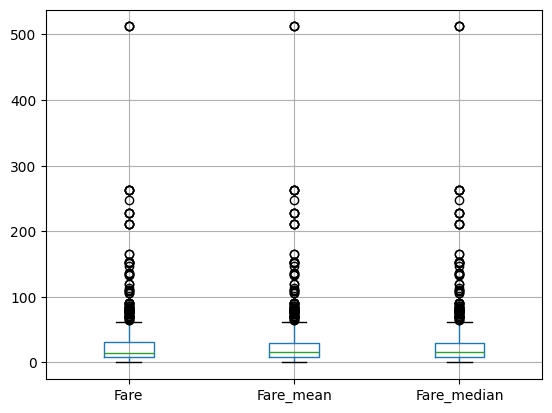

In [34]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

using sklearn simple imputer



In [36]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [38]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [40]:
X_train.isnull().mean()*100

,0
Age,20.786517
Fare,5.056180
Family,0.000000


In [45]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')


In [46]:
trf=ColumnTransformer([('imputer1',imputer1,['Age']),('imputer2',imputer2,['Fare'])],remainder='passthrough')

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [67]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])